# Modelo Baseline
Por Mateo Soto

Última actualización: 21/Ago/2026

## Description
Entrenamiento y evaluación de un modelo heurístico formal (Regresión Lineal sobre `rm` y
`lstat`), usando el pipeline de Feature Engineering del Paso 4, para establecer la referencia
base a superar en la Selección del mejor modelo (Paso 6).


## 📚 Import  libraries

In [16]:
# base libraries for data science

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, ShuffleSplit, cross_validate, learning_curve

print("Python version: ", sys.version)

Python version:  3.12.13 (main, Jul 23 2026, 14:43:28) [Clang 22.1.3 ]


## 💾 Load data

## 💾 Load data

Se reutilizan `x_train`/`x_test` ya transformados por el pipeline de Feature Engineering
(Paso 4) — log-transform, escalado e imputación ya aplicados.

In [17]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"
MODELS_DIR = Path.cwd().resolve().parents[1] / "models"

x_train = pd.read_parquet(DATA_DIR / "03_primary/x_train.parquet")
x_test = pd.read_parquet(DATA_DIR / "03_primary/x_test.parquet")
y_train = pd.read_parquet(DATA_DIR / "03_primary/y_train.parquet")["medv"]
y_test = pd.read_parquet(DATA_DIR / "03_primary/y_test.parquet")["medv"]

x_train.shape, y_train.shape


((273, 11), (273,))

In [18]:
x_test.shape, y_test.shape

((69, 11), (69,))

## 👷 Data preparation or Feature Engineering

## 👷 Data preparation — Selección de la variable más importante

`lstat` es la variable individual más correlacionada con `medv` (Pearson -0.76, Spearman
-0.88 — la relación no lineal más fuerte del dataset, análisis bivariable). Como segunda
variable, `rm` (Pearson 0.69) fue la única con relación Pearson-Spearman consistente
(0.69 vs. 0.59), sugiriendo linealidad genuina, y con baja redundancia frente a `lstat`
(confirmado con VIF en el análisis multivariable).

Se seleccionan **`lstat` y `rm`** como base del modelo heurístico, formalizando con
metodología rigurosa (cross-validation, learning curve) el heurístico manual calculado en
el EDA (MAE 3.84 sobre todo el dataset, sin train/test split real).

In [19]:
cols_baseline = ["numeric__rm", "log__lstat"]
x_train_baseline = x_train[cols_baseline]
x_test_baseline = x_test[cols_baseline]
x_train_baseline.head()


,numeric__rm,log__lstat
0,-0.597497,-0.216684
1,-0.242165,-0.109791
2,-0.549519,-0.010219
3,-0.846378,0.795411
4,-0.023269,-0.031004


## 📏 Selección de la métrica principal

Se elige **MAE (Error Absoluto Medio)** como métrica principal:
1. Interpretable directamente en miles de USD — más claro para comunicar a un stakeholder
   no técnico que RMSE.
2. Más robusta frente a la censura documentada en `medv` (14 registros con valor exacto
   50.0): RMSE penaliza cuadráticamente esos errores, inflando la métrica por una
   limitación conocida de los datos, no por un fallo real del modelo.

RMSE y R² se reportan como métricas secundarias.

## 🤖 Modelo — Regresión Lineal (heurístico formal)

In [20]:
modelo_heuristico = LinearRegression()
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scoring_metrics = ["neg_mean_absolute_error", "neg_root_mean_squared_error", "r2"]

cv_results = cross_validate(
    modelo_heuristico, x_train_baseline, y_train, cv=kfold, scoring=scoring_metrics
)

for metric in scoring_metrics:
    scores = cv_results[f"test_{metric}"]
    print(f"{metric} - CV mean: {scores.mean():.3f}, CV std: {scores.std():.3f}")


neg_mean_absolute_error - CV mean: -3.492, CV std: 0.604
neg_root_mean_squared_error - CV mean: -4.743, CV std: 1.139
r2 - CV mean: 0.655, CV std: 0.075


### Comparación: modelo formal vs. heurístico manual del EDA

| Métrica | Heurístico manual (EDA) | Modelo formal (CV) |
|---|---|---|
| MAE | 3.84 | **3.49** |
| RMSE | 5.33 | **4.74** |
| R² | — | 0.655 |

El modelo formalizado con pipeline (log-transform + escalado + train/test split correcto)
mejora sobre el cálculo manual del EDA en ambas métricas. El R² de 0.655 confirma que
`rm` + `lstat` explican una mayoría significativa de la varianza de `medv`, dejando ~35%
de varianza sin explicar — margen de mejora esperado para los modelos más complejos del
Paso 6, que incorporarán las 11 variables disponibles.

La desviación estándar entre folds (MAE std: 0.60, ~17% del valor medio) es moderada,
consistente con el tamaño relativamente pequeño del dataset (273 filas de entrenamiento).

### Comparación contra DummyRegressor (piso ingenuo)

Equivalente al "promedio global" calculado manualmente en el EDA (MAE 6.67).

In [21]:
modelo_dummy = DummyRegressor(strategy="mean")
cv_dummy = cross_validate(
    modelo_dummy, x_train_baseline, y_train, cv=kfold, scoring=scoring_metrics
)

comparacion = pd.DataFrame(
    {
        "Dummy (promedio)": [
            -cv_dummy["test_neg_mean_absolute_error"].mean(),
            -cv_dummy["test_neg_root_mean_squared_error"].mean(),
            cv_dummy["test_r2"].mean(),
        ],
        "Heurístico (rm+lstat)": [
            -cv_results["test_neg_mean_absolute_error"].mean(),
            -cv_results["test_neg_root_mean_squared_error"].mean(),
            cv_results["test_r2"].mean(),
        ],
    },
    index=["MAE", "RMSE", "R2"],
)
comparacion


,Dummy (promedio),Heurístico (rm+lstat)
MAE,6.440291,3.491611
RMSE,8.566499,4.743050
R2,-0.085975,0.654747


### Comparación completa: Dummy vs. Heurístico (validación cruzada)

| Métrica | Dummy (promedio) | Heurístico (rm+lstat) | Mejora |
|---|---|---|---|
| MAE | 6.44 | **3.49** | -46% |
| RMSE | 8.57 | **4.74** | -45% |
| R² | -0.09 | **0.65** | — |

El R² negativo del Dummy es un resultado técnico esperado (no un error): al no tener
capacidad predictiva real, su error bajo validación cruzada puede superar ligeramente a la
varianza total de los datos, generando un R² por debajo de cero. Esto no invalida la
comparación — de hecho, refuerza que `rm` y `lstat` aportan señal predictiva sustancial
(MAE 46% menor, R² de 0.65 vs. prácticamente nulo del Dummy).

## 📈 Learning Curve

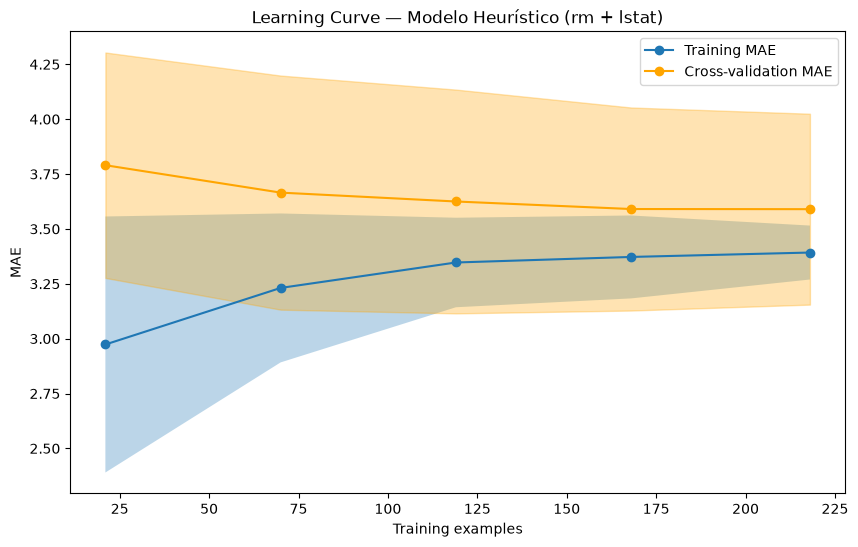

In [22]:
common_params = {
    "X": x_train_baseline,
    "y": y_train,
    "train_sizes": np.linspace(0.1, 1.0, 5),
    "cv": ShuffleSplit(n_splits=50, test_size=0.2, random_state=123),
    "n_jobs": -1,
    "return_times": True,
    "scoring": "neg_mean_absolute_error",
}
train_sizes, train_scores, test_scores, fit_times, score_times = learning_curve(
    modelo_heuristico, **common_params
)

train_mean, test_mean = -train_scores.mean(axis=1), -test_scores.mean(axis=1)
train_std, test_std = train_scores.std(axis=1), test_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, "o-", label="Training MAE")
ax.plot(train_sizes, test_mean, "o-", color="orange", label="Cross-validation MAE")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.3)
ax.fill_between(
    train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.3, color="orange"
)
ax.set_title("Learning Curve — Modelo Heurístico (rm + lstat)")
ax.set_xlabel("Training examples")
ax.set_ylabel("MAE")
ax.legend(loc="best")
plt.show()


In [23]:
print("Training Sizes:", train_sizes)
print("Training MAE Mean:", train_mean)
print("Training MAE Std:", train_std)
print("Test MAE Mean:", test_mean)
print("Test MAE Std:", test_std)

Training Sizes: [ 21  70 119 168 218]
Training MAE Mean: [2.97345348 3.23116444 3.3470401  3.37233105 3.39240242]
Training MAE Std: [0.58322476 0.33927678 0.20393147 0.18890655 0.12291479]
Test MAE Mean: [3.79028599 3.66544253 3.62498284 3.59064447 3.59000251]
Test MAE Std: [0.51354084 0.53326673 0.5098241  0.46255127 0.434845  ]


## ⏱ Escalabilidad — tiempo de entrenamiento y score

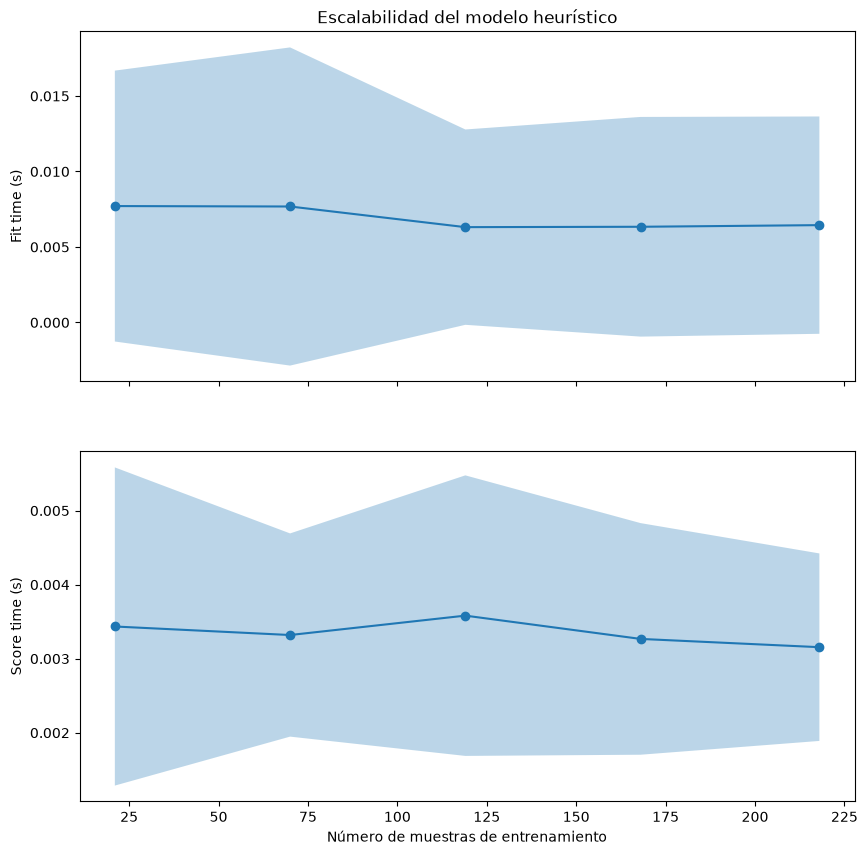

In [24]:
fit_times_mean, fit_times_std = fit_times.mean(axis=1), fit_times.std(axis=1)
score_times_mean, score_times_std = score_times.mean(axis=1), score_times.std(axis=1)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

ax[0].plot(train_sizes, fit_times_mean, "o-")
ax[0].fill_between(
    train_sizes,
    fit_times_mean - fit_times_std,
    fit_times_mean + fit_times_std,
    alpha=0.3,
)
ax[0].set_ylabel("Fit time (s)")
ax[0].set_title("Escalabilidad del modelo heurístico")

ax[1].plot(train_sizes, score_times_mean, "o-")
ax[1].fill_between(
    train_sizes,
    score_times_mean - score_times_std,
    score_times_mean + score_times_std,
    alpha=0.3,
)
ax[1].set_ylabel("Score time (s)")
ax[1].set_xlabel("Número de muestras de entrenamiento")
plt.show()


In [25]:
print("Fit Times Mean:", fit_times_mean)
print("Score Times Mean:", score_times_mean)

Fit Times Mean: [0.0077096  0.00768099 0.00631343 0.00633785 0.00644638]
Score Times Mean: [0.00343493 0.00331982 0.00358162 0.00326721 0.00315559]


## ✅ Evaluación final en test

In [26]:
modelo_heuristico.fit(x_train_baseline, y_train)
pred_test = modelo_heuristico.predict(x_test_baseline)

print(f"MAE test:  {mean_absolute_error(y_test, pred_test):.2f}")
print(f"RMSE test: {mean_squared_error(y_test, pred_test) ** 0.5:.2f}")
print(f"R2 test:   {r2_score(y_test, pred_test):.3f}")
print(
    f"Coeficientes: rm={modelo_heuristico.coef_[0]:.2f}, "
    f"lstat={modelo_heuristico.coef_[1]:.2f}"
)


MAE test:  3.93
RMSE test: 5.82
R2 test:   0.662
Coeficientes: rm=2.53, lstat=-5.53


### Evaluación final en test

| Métrica | CV (10 folds) | Test final |
|---|---|---|
| MAE | 3.49 | 3.93 |
| RMSE | 4.74 | 5.82 |
| R² | 0.655 | **0.662** |

El desempeño en test es consistente con la validación cruzada — la diferencia en MAE/RMSE
cae dentro de una desviación estándar del promedio de CV (std: 0.60), y el R² es
prácticamente idéntico, confirmando estabilidad del modelo.

**Interpretación de coeficientes** (sobre variables transformadas — escaladas, `lstat` con
log1p): `rm` (+2.53) y `lstat` (-5.53) tienen el signo esperado según el EDA. La magnitud
mayor de `lstat` confirma cuantitativamente que es la variable con mayor poder predictivo
individual sobre `medv` (Pearson -0.76, la correlación más fuerte del dataset).

### Predicho vs. Real — diagnóstico visual de errores

Equivalente en regresión a la matriz de confusión en clasificación: permite ver *dónde*
falla el modelo, no solo *cuánto* falla en promedio.

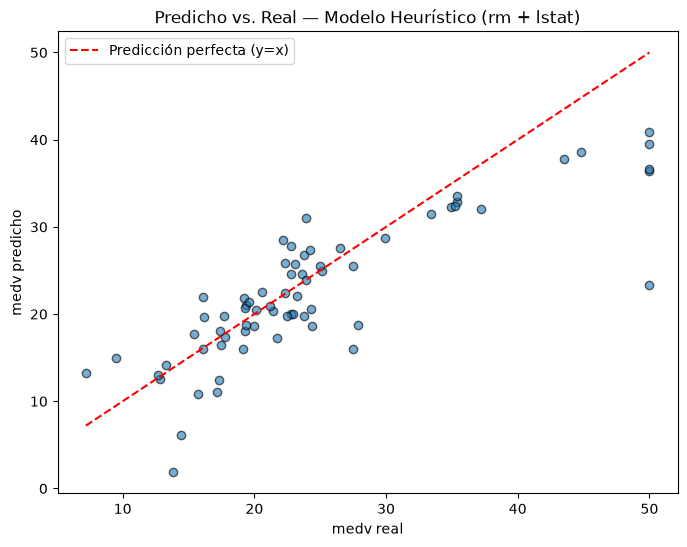

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, pred_test, alpha=0.6, edgecolor="k")
ax.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    label="Predicción perfecta (y=x)",
)
ax.set_xlabel("medv real")
ax.set_ylabel("medv predicho")
ax.set_title("Predicho vs. Real — Modelo Heurístico (rm + lstat)")
ax.legend()
plt.show()


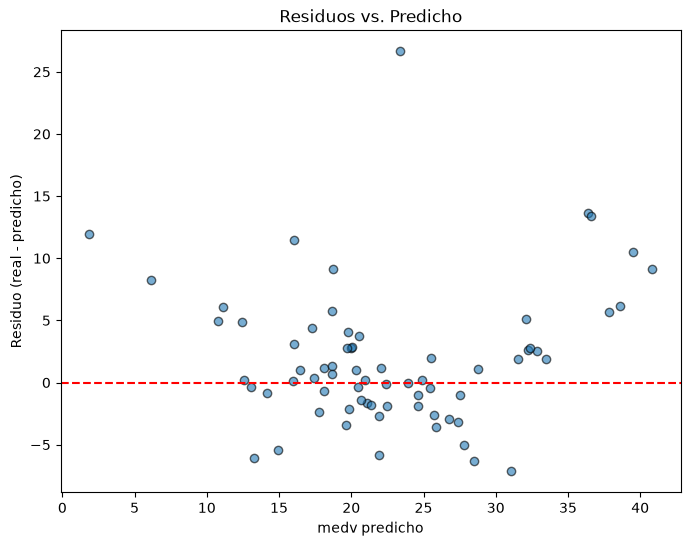

In [28]:
residuos = y_test - pred_test

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(pred_test, residuos, alpha=0.6, edgecolor="k")
ax.axhline(0, color="r", linestyle="--")
ax.set_xlabel("medv predicho")
ax.set_ylabel("Residuo (real - predicho)")
ax.set_title("Residuos vs. Predicho")
plt.show()

## 💾 Guardar modelo

In [29]:
import joblib

joblib.dump(modelo_heuristico, MODELS_DIR / "baseline_heuristico.joblib")


['/home/usuariomateosoto/Precios_Casas_Boston/models/baseline_heuristico.joblib']

## 📊 Analysis of Results and Conclusions 

Description of the results obtained and if there are conclusions that can be drawn from them.

The analysis of results must be related to the description of the task.

**Note:** An analysis of results does not necessarily lead to conclusions, but to ideas or proposals for future work


## 📊 Analysis of Results and Conclusions

### Resumen de resultados

| Métrica | Dummy (promedio) | Heurístico CV (10 folds) | Heurístico Test final | Heurístico manual (EDA) |
|---|---|---|---|---|
| MAE | 6.44 | 3.49 (±0.60) | 3.93 | 3.84 |
| RMSE | 8.57 | 4.74 (±1.14) | 5.82 | 5.33 |
| R² | -0.09 | 0.655 (±0.075) | 0.662 | — |

### Desempeño del modelo

El modelo heurístico formalizado (`rm` + `lstat`, vía pipeline de Feature Engineering)
reduce el MAE en **~46%** respecto a la predicción ingenua del promedio (Dummy), confirmando
que ambas variables aportan señal predictiva real y sustancial. El R² de 0.66 indica que el
modelo explica dos tercios de la varianza de `medv` usando solo 2 de las 11 variables
disponibles en el dataset — un punto de partida sólido para el resto del proyecto.

El desempeño en el set de test final (MAE 3.93, R² 0.662) es consistente con la validación
cruzada (MAE 3.49±0.60, R² 0.655±0.075): la diferencia en MAE cae dentro de una desviación
estándar del promedio de CV, y el R² es prácticamente idéntico entre ambas evaluaciones —
señal de que el modelo generaliza de forma estable, sin depender de una partición específica
de los datos.

Comparado con el heurístico manual calculado en el EDA (MAE 3.84, sin pipeline ni split real),
el modelo formal mejora la métrica en cross-validation (3.49) pero queda ligeramente por
encima en el test final (3.93) — ambos resultados razonablemente cercanos, confirmando que
las transformaciones del Paso 4 (especialmente el log-transform en `lstat`) capturan
correctamente la relación no lineal ya documentada en el EDA.

### Interpretación de coeficientes

`rm` (+2.53) y `lstat` (-5.53) muestran el signo esperado según el análisis exploratorio:
más cuartos incrementa el precio, mayor proporción de población de estatus socioeconómico
bajo lo reduce. La magnitud más del doble de `lstat` frente a `rm` confirma cuantitativamente
que `lstat` es la variable con mayor poder predictivo